A prediction is correct only if BOTH:
1. The extracted skill span matches a gold span
2. The predicted ESCO ID matches the gold ESCO ID

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/CS685/linkedin")

Mounted at /content/drive


Load All Data

In [ ]:
# Load gold ESCO annotations
gold_esco = pd.read_csv(BASE / "test_gold_esco.csv")
print(f"Gold ESCO annotations: {len(gold_esco)} skill mentions")
print(f"Columns: {gold_esco.columns.tolist()}")
print(f"\nSample:")
print(gold_esco.head(3))

Gold ESCO annotations: 190 skill mentions
Columns: ['sent_id', 'sentence', 'skill_mention', 'esco_id', 'esco_label', 'notes', 'esco_id_clean']

Sample:
        sent_id                                           sentence  \
0  3899518313_3  As our Software Displays Engineer team member ...   
1  3901375559_0  Job title : Mainframe developerLocation : Mcle...   
2  3901375559_0  Job title : Mainframe developerLocation : Mcle...   

                                       skill_mention  \
0  designing and developing Display Platform soft...   
1                                            Eclipse   
2                                               Java   

                                             esco_id  \
0                                                NIL   
1  http://data.europa.eu/esco/skill/6b6a9252-2ed7...   
2  http://data.europa.eu/esco/skill/19a8293b-8e95...   

                                          esco_label  notes  \
0                                                NaN  

In [ ]:
# Load extraction predictions (BIO tags from DistilBERT)
extraction_preds = pd.read_csv(BASE / "distilbert_runA_test_wordlevel_preds.csv")
print(f"\nExtraction predictions: {len(extraction_preds)} rows")
print(f"Columns: {extraction_preds.columns.tolist()}")
print(f"\nSample:")
print(extraction_preds.head(3))


Extraction predictions: 105 rows
Columns: ['tokens', 'gold_tags', 'pred_tags']

Sample:
                                              tokens  \
0  ['Skills', 'and', 'Expertise', ':', 'Expertise...   
1  ['Good', 'knowledge', 'of', 'the', 'product', ...   
2  ['You', 'will', 'be', 'a', 'part', 'of', 'Soft...   

                                           gold_tags  \
0  ['O', 'O', 'O', 'O', 'O', 'O', 'B-SKILL', 'O',...   
1  ['O', 'O', 'O', 'O', 'O', 'O', 'B-SKILL', 'I-S...   
2  ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...   

                                           pred_tags  
0  ['O', 'O', 'O', 'O', 'O', 'O', 'B-SKILL', 'O',...  
1  ['O', 'O', 'O', 'O', 'O', 'O', 'B-SKILL', 'I-S...  
2  ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...  


In [ ]:
# Load normalization results
# Use v2 if available, otherwise v1
if (BASE / "skill_normalization_results_v2.csv").exists():
    norm_results = pd.read_csv(BASE / "skill_normalization_results_v2.csv")
    print("Using normalization v2 results")
else:
    norm_results = pd.read_csv(BASE / "skill_normalization_results_v1.csv")
    print("Using normalization v1 results")

print(f"\nNormalization results: {len(norm_results)} skill mentions")
print(f"Columns: {norm_results.columns.tolist()}")
print(f"\nSample:")
print(norm_results.head(3))

Using normalization v2 results

Normalization results: 197 skill mentions
Columns: ['idx', 'sentence', 'mention', 'skill_id', 'preferred_label', 'matched_variant', 'score', 'method', 'is_nil']

Sample:
   idx                                           sentence  \
0    0  Skills and Expertise : Expertise in linguistic...   
1    0  Skills and Expertise : Expertise in linguistic...   
2    0  Skills and Expertise : Expertise in linguistic...   

                    mention  \
0               linguistics   
1          machine learning   
2  computational algorithms   

                                            skill_id   preferred_label  \
0  http://data.europa.eu/esco/skill/810df100-e85a...       linguistics   
1  http://data.europa.eu/esco/skill/3a2d5b45-56e4...  machine learning   
2  http://data.europa.eu/esco/skill/54924a2c-daca...        algorithms   

    matched_variant  score           method  is_nil  
0       linguistics   1.00      exact_match   False  
1  machine learning   1

In [ ]:
# Load test data to get sent_id mapping
test_bio = pd.read_csv(BASE / "ner_data_v3/bio_test.csv")
print(f"\nTest BIO data: {len(test_bio)} rows")
print(f"Unique sentences: {test_bio['sent_id'].nunique()}")


Test BIO data: 105 rows
Unique sentences: 105


Extract Predicted Skills from BIO Tags

In [ ]:
def bio_to_spans(tokens, bio_tags):
    spans = []
    current_span = []

    for i, (token, tag) in enumerate(zip(tokens, bio_tags)):
        if tag == 'B-SKILL':
            # Start new span
            if current_span:
                spans.append(' '.join(current_span))
            current_span = [token]
        elif tag == 'I-SKILL':
            # Continue span
            if current_span:
                current_span.append(token)
            else:
                # Orphaned I-tag, treat as B
                current_span = [token]
        else:  # O tag
            if current_span:
                spans.append(' '.join(current_span))
                current_span = []

    # Don't forget last span
    if current_span:
        spans.append(' '.join(current_span))

    return spans

# Test the function
test_tokens = ['Experience', 'with', 'Python', 'and', 'Java', 'required']
test_tags = ['O', 'O', 'B-SKILL', 'O', 'B-SKILL', 'O']
print("Test:")
print(f"Tokens: {test_tokens}")
print(f"Tags: {test_tags}")
print(f"Spans: {bio_to_spans(test_tokens, test_tags)}")

Test:
Tokens: ['Experience', 'with', 'Python', 'and', 'Java', 'required']
Tags: ['O', 'O', 'B-SKILL', 'O', 'B-SKILL', 'O']
Spans: ['Python', 'Java']


In [ ]:
import ast

# Extract predicted spans for each test sentence
def parse_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

# Parse tokens and tags
extraction_preds['tokens_list'] = extraction_preds['tokens'].apply(parse_list)
extraction_preds['pred_tags_list'] = extraction_preds['pred_tags'].apply(parse_list)

# Extract predicted skill spans
extraction_preds['predicted_spans'] = extraction_preds.apply(
    lambda row: bio_to_spans(row['tokens_list'], row['pred_tags_list']),
    axis=1
)

print(f"Extracted spans for {len(extraction_preds)} test sentences")
print(f"\nSample:")
print(extraction_preds[['predicted_spans']].head(5))

Extracted spans for 105 test sentences

Sample:
                                     predicted_spans
0  [linguistics, machine learning, computational ...
1  [BPM Fundamentals, Architecture Components, Ap...
2                                                 []
3                                               [UI]
4  [Sync / Async concepts, uWSGI / ASGI, websocke...


Map Sentences to sent_id

In [ ]:
# Need to add sent_id to extraction_preds
# The test_bio has sent_id, let's use that

# Get unique sent_ids from test_bio (in order)
sent_id_order = test_bio['sent_id'].unique()
print(f"Test set has {len(sent_id_order)} unique sentences")

# extraction_preds should have same number of rows
if len(extraction_preds) == len(sent_id_order):
    extraction_preds['sent_id'] = sent_id_order
    print("✓ Mapped sent_id to extraction predictions")
else:
    print(f"Warning: Mismatch - {len(extraction_preds)} predictions vs {len(sent_id_order)} sentences")
    # Try to match by joining with test_bio on some other column if needed

print(f"\nSample with sent_id:")
print(extraction_preds[['sent_id', 'predicted_spans']].head())

Test set has 105 unique sentences
✓ Mapped sent_id to extraction predictions

Sample with sent_id:
        sent_id                                    predicted_spans
0  3888824427_9  [linguistics, machine learning, computational ...
1  3903871852_1  [BPM Fundamentals, Architecture Components, Ap...
2  3888438098_1                                                 []
3  3905216012_2                                               [UI]
4  3901939205_7  [Sync / Async concepts, uWSGI / ASGI, websocke...


Build Gold and Predicted Lookups

In [ ]:
# Build gold lookup: sent_id → [(skill_text, esco_id), ...]
gold_by_sent = defaultdict(list)

for _, row in gold_esco.iterrows():
    gold_by_sent[row['sent_id']].append({
        'skill': row['skill_mention'].lower().strip(),
        'esco_id': row['esco_id_clean']
    })

print(f"Gold data: {len(gold_by_sent)} sentences with skills")
print(f"Total gold skill mentions: {len(gold_esco)}")

# Show sample
sample_sent_id = list(gold_by_sent.keys())[0]
print(f"\nSample sentence: {sample_sent_id}")
print(f"Gold skills: {gold_by_sent[sample_sent_id]}")

Gold data: 64 sentences with skills
Total gold skill mentions: 190

Sample sentence: 3899518313_3
Gold skills: [{'skill': 'designing and developing display platform software', 'esco_id': 'NIL'}]


In [ ]:
# Build normalization lookup: mention → esco_id
# Note: norm_results has 'mention' column and we need to map it to ESCO ID

# Load ESCO to get the mapping from preferred_label to ID
esco = pd.read_csv("/content/drive/MyDrive/CS685/esco/skills_en.csv")

# Create mapping from preferredLabel to ESCO ID
def extract_esco_id_from_uri(uri):
    if pd.isna(uri):
        return None
    return uri.split('/')[-1]

esco['esco_id'] = esco['conceptUri'].apply(extract_esco_id_from_uri)
esco_label_to_id = dict(zip(esco['preferredLabel'], esco['esco_id']))

print(f"ESCO taxonomy: {len(esco)} skills")
print(f"Label to ID mapping: {len(esco_label_to_id)} entries")

ESCO taxonomy: 13939 skills
Label to ID mapping: 13939 entries


In [ ]:
# Create normalized skill lookup: mention → esco_id
norm_lookup = {}

for _, row in norm_results.iterrows():
    mention = str(row['mention']).lower().strip()

    # Check if it's NIL
    if pd.isna(row['preferred_label']) or row['method'] == 'NIL':
        norm_lookup[mention] = 'NIL'
    else:
        # Get ESCO ID from label
        label = row['preferred_label']
        esco_id = esco_label_to_id.get(label, 'NIL')
        norm_lookup[mention] = esco_id

print(f"Normalization lookup: {len(norm_lookup)} mentions")
print(f"NIL mappings: {sum(1 for v in norm_lookup.values() if v == 'NIL')}")

# Show samples
print(f"\nSample mappings:")
for mention, esco_id in list(norm_lookup.items())[:5]:
    print(f"  {mention} → {esco_id}")

Normalization lookup: 174 mentions
NIL mappings: 57

Sample mappings:
  linguistics → 810df100-e85a-4c13-b619-34030a75ecc2
  machine learning → 3a2d5b45-56e4-4f5a-a55a-4a4a65afdc43
  computational algorithms → 54924a2c-daca-40d3-9716-4b38ceb04f38
  programming languages → 495ce586-09d7-4cec-83d7-2821be6590c4
  python → ccd0a1d9-afda-43d9-b901-96344886e14d


In [ ]:
# Build prediction lookup: sent_id → [(skill_text, predicted_esco_id), ...]
pred_by_sent = defaultdict(list)

for _, row in extraction_preds.iterrows():
    sent_id = row['sent_id']
    predicted_spans = row['predicted_spans']

    for skill_text in predicted_spans:
        # Normalize skill text
        skill_lower = skill_text.lower().strip()

        # Look up ESCO ID from normalization results
        predicted_esco_id = norm_lookup.get(skill_lower, 'UNKNOWN')

        pred_by_sent[sent_id].append({
            'skill': skill_lower,
            'esco_id': predicted_esco_id
        })

print(f"Predictions: {len(pred_by_sent)} sentences with predicted skills")
total_pred = sum(len(skills) for skills in pred_by_sent.values())
print(f"Total predicted skill mentions: {total_pred}")

# Show sample
if len(pred_by_sent) > 0:
    sample_sent_id = list(pred_by_sent.keys())[0]
    print(f"\nSample sentence: {sample_sent_id}")
    print(f"Predicted skills: {pred_by_sent[sample_sent_id]}")

Predictions: 59 sentences with predicted skills
Total predicted skill mentions: 197

Sample sentence: 3888824427_9
Predicted skills: [{'skill': 'linguistics', 'esco_id': '810df100-e85a-4c13-b619-34030a75ecc2'}, {'skill': 'machine learning', 'esco_id': '3a2d5b45-56e4-4f5a-a55a-4a4a65afdc43'}, {'skill': 'computational algorithms', 'esco_id': '54924a2c-daca-40d3-9716-4b38ceb04f38'}, {'skill': 'programming languages', 'esco_id': '495ce586-09d7-4cec-83d7-2821be6590c4'}, {'skill': 'python', 'esco_id': 'ccd0a1d9-afda-43d9-b901-96344886e14d'}, {'skill': 'nlp', 'esco_id': 'fff0e2cd-d0bd-4b02-9daf-158b79d9688a'}, {'skill': 'sentiment analysis', 'esco_id': 'd523d7bf-cb3d-4310-9bf3-5670659c9b83'}, {'skill': 'chatbot development', 'esco_id': 'NIL'}, {'skill': 'language generation models', 'esco_id': 'b6f26b50-3914-46ff-8f88-3defb71e007a'}, {'skill': 'nlp', 'esco_id': 'fff0e2cd-d0bd-4b02-9daf-158b79d9688a'}]


Matching Functions

In [ ]:
def normalize_text(text):
    return text.lower().strip()

def exact_match(pred_skill, gold_skill):
    return normalize_text(pred_skill) == normalize_text(gold_skill)

def lenient_match(pred_skill, gold_skill):
    pred = normalize_text(pred_skill)
    gold = normalize_text(gold_skill)

    # Exact match
    if pred == gold:
        return True

    # One contains the other (for boundary errors)
    if pred in gold or gold in pred:
        return True

    return False

# Test
print("Testing matching functions:")
print(f"exact_match('Python', 'python'): {exact_match('Python', 'python')}")
print(f"exact_match('Python', 'Python programming'): {exact_match('Python', 'Python programming')}")
print(f"lenient_match('Python', 'Python programming'): {lenient_match('Python', 'Python programming')}")

Testing matching functions:
exact_match('Python', 'python'): True
exact_match('Python', 'Python programming'): False
lenient_match('Python', 'Python programming'): True


End-to-End Evaluation

In [ ]:
def evaluate_end_to_end(gold_by_sent, pred_by_sent, match_fn):
    """
    Evaluate end-to-end performance.

    A prediction is correct only if BOTH:
    1. Skill span matches (according to match_fn)
    2. ESCO ID matches

    Args:
        gold_by_sent: dict mapping sent_id to list of {skill, esco_id}
        pred_by_sent: dict mapping sent_id to list of {skill, esco_id}
        match_fn: function(pred_skill, gold_skill) -> bool

    Returns:
        dict with metrics
    """
    tp = 0  # True positives: both skill and ESCO ID match
    fp = 0  # False positives: predicted but no match
    fn = 0  # False negatives: gold but not predicted

    # For error analysis
    span_correct_esco_wrong = 0  # Extraction right, normalization wrong
    span_wrong = 0  # Extraction wrong

    # Get all sentence IDs
    all_sent_ids = set(gold_by_sent.keys()) | set(pred_by_sent.keys())

    for sent_id in all_sent_ids:
        gold_skills = gold_by_sent.get(sent_id, [])
        pred_skills = pred_by_sent.get(sent_id, [])

        # Track which gold/pred items have been matched
        matched_gold = set()
        matched_pred = set()

        # Try to match each prediction to a gold skill
        for i, pred in enumerate(pred_skills):
            found_match = False

            for j, gold in enumerate(gold_skills):
                if j in matched_gold:
                    continue

                # Check if skill span matches
                span_matches = match_fn(pred['skill'], gold['skill'])

                if span_matches:
                    # Check if ESCO ID also matches
                    esco_matches = (pred['esco_id'] == gold['esco_id'])

                    if esco_matches:
                        # Perfect match!
                        tp += 1
                        matched_gold.add(j)
                        matched_pred.add(i)
                        found_match = True
                        break
                    else:
                        # Span correct but ESCO wrong
                        span_correct_esco_wrong += 1
                        matched_gold.add(j)
                        matched_pred.add(i)
                        found_match = True
                        break

            if not found_match:
                # This prediction doesn't match any gold
                span_wrong += 1

        # Unmatched predictions are false positives
        fp += len(pred_skills) - len(matched_pred)

        # Unmatched gold skills are false negatives
        fn += len(gold_skills) - len(matched_gold)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'span_correct_esco_wrong': span_correct_esco_wrong,
        'span_wrong': span_wrong
    }

# Evaluate with strict matching
print("="*70)
print("END-TO-END EVALUATION (STRICT MATCHING)")
print("="*70)
strict_results = evaluate_end_to_end(gold_by_sent, pred_by_sent, exact_match)

print(f"\nTrue Positives: {strict_results['tp']}")
print(f"False Positives: {strict_results['fp']}")
print(f"False Negatives: {strict_results['fn']}")
print(f"\nPrecision: {strict_results['precision']:.3f}")
print(f"Recall: {strict_results['recall']:.3f}")
print(f"F1: {strict_results['f1']:.3f}")
print(f"\nError breakdown:")
print(f"  Span correct, ESCO wrong: {strict_results['span_correct_esco_wrong']}")
print(f"  Span wrong: {strict_results['span_wrong']}")

# Evaluate with lenient matching
print("\n" + "="*70)
print("END-TO-END EVALUATION (LENIENT MATCHING)")
print("="*70)
lenient_results = evaluate_end_to_end(gold_by_sent, pred_by_sent, lenient_match)

print(f"\nTrue Positives: {lenient_results['tp']}")
print(f"False Positives: {lenient_results['fp']}")
print(f"False Negatives: {lenient_results['fn']}")
print(f"\nPrecision: {lenient_results['precision']:.3f}")
print(f"Recall: {lenient_results['recall']:.3f}")
print(f"F1: {lenient_results['f1']:.3f}")
print(f"\nError breakdown:")
print(f"  Span correct, ESCO wrong: {lenient_results['span_correct_esco_wrong']}")
print(f"  Span wrong: {lenient_results['span_wrong']}")

END-TO-END EVALUATION (STRICT MATCHING)

True Positives: 54
False Positives: 97
False Negatives: 90

Precision: 0.358
Recall: 0.375
F1: 0.366

Error breakdown:
  Span correct, ESCO wrong: 46
  Span wrong: 97

END-TO-END EVALUATION (LENIENT MATCHING)

True Positives: 64
False Positives: 58
False Negatives: 51

Precision: 0.525
Recall: 0.557
F1: 0.540

Error breakdown:
  Span correct, ESCO wrong: 75
  Span wrong: 58


Bootstrap Confidence Intervals

In [ ]:
def bootstrap_f1(gold_by_sent, pred_by_sent, match_fn, n_bootstrap=1000, random_seed=42):
    """
    Calculate F1 with 95% confidence intervals using bootstrap resampling.

    Args:
        gold_by_sent: dict
        pred_by_sent: dict
        match_fn: matching function
        n_bootstrap: number of bootstrap samples
        random_seed: for reproducibility

    Returns:
        tuple: (mean_f1, ci_low, ci_high)
    """
    np.random.seed(random_seed)

    # Get all sentence IDs
    all_sent_ids = list(set(gold_by_sent.keys()) | set(pred_by_sent.keys()))
    n_sentences = len(all_sent_ids)

    f1_scores = []

    for _ in range(n_bootstrap):
        # Resample sentences with replacement
        sample_ids = np.random.choice(all_sent_ids, size=n_sentences, replace=True)

        # Create sampled gold and pred
        sample_gold = {sid: gold_by_sent.get(sid, []) for sid in sample_ids}
        sample_pred = {sid: pred_by_sent.get(sid, []) for sid in sample_ids}

        # Evaluate on this sample
        results = evaluate_end_to_end(sample_gold, sample_pred, match_fn)
        f1_scores.append(results['f1'])

    # Calculate 95% CI
    ci_low = np.percentile(f1_scores, 2.5)
    ci_high = np.percentile(f1_scores, 97.5)
    mean_f1 = np.mean(f1_scores)

    return mean_f1, ci_low, ci_high

print("Calculating bootstrap confidence intervals...")
print("(This may take 1-2 minutes)\n")

# Strict matching
strict_mean, strict_low, strict_high = bootstrap_f1(
    gold_by_sent, pred_by_sent, exact_match, n_bootstrap=1000
)
print(f"Strict F1: {strict_mean:.3f} [95% CI: {strict_low:.3f}, {strict_high:.3f}]")

# Lenient matching
lenient_mean, lenient_low, lenient_high = bootstrap_f1(
    gold_by_sent, pred_by_sent, lenient_match, n_bootstrap=1000
)
print(f"Lenient F1: {lenient_mean:.3f} [95% CI: {lenient_low:.3f}, {lenient_high:.3f}]")

Calculating bootstrap confidence intervals...
(This may take 1-2 minutes)

Strict F1: 0.365 [95% CI: 0.295, 0.422]
Lenient F1: 0.538 [95% CI: 0.462, 0.599]


## Save Results

In [ ]:
# Create results summary
results_summary = pd.DataFrame([
    {
        'matching': 'Strict',
        'precision': strict_results['precision'],
        'recall': strict_results['recall'],
        'f1': strict_results['f1'],
        'f1_ci_low': strict_low,
        'f1_ci_high': strict_high,
        'tp': strict_results['tp'],
        'fp': strict_results['fp'],
        'fn': strict_results['fn']
    },
    {
        'matching': 'Lenient',
        'precision': lenient_results['precision'],
        'recall': lenient_results['recall'],
        'f1': lenient_results['f1'],
        'f1_ci_low': lenient_low,
        'f1_ci_high': lenient_high,
        'tp': lenient_results['tp'],
        'fp': lenient_results['fp'],
        'fn': lenient_results['fn']
    }
])

print("\nResults Summary:")
print(results_summary.to_string(index=False))

# Save
results_summary.to_csv(BASE / "end_to_end_results.csv", index=False)
print(f"\n✓ Saved: {BASE / 'end_to_end_results.csv'}")


Results Summary:
matching  precision   recall       f1  f1_ci_low  f1_ci_high  tp  fp  fn
  Strict   0.357616 0.375000 0.366102   0.294862    0.422146  54  97  90
 Lenient   0.524590 0.556522 0.540084   0.462476    0.598726  64  58  51

✓ Saved: /content/drive/MyDrive/CS685/linkedin/end_to_end_results.csv


## Visualizations

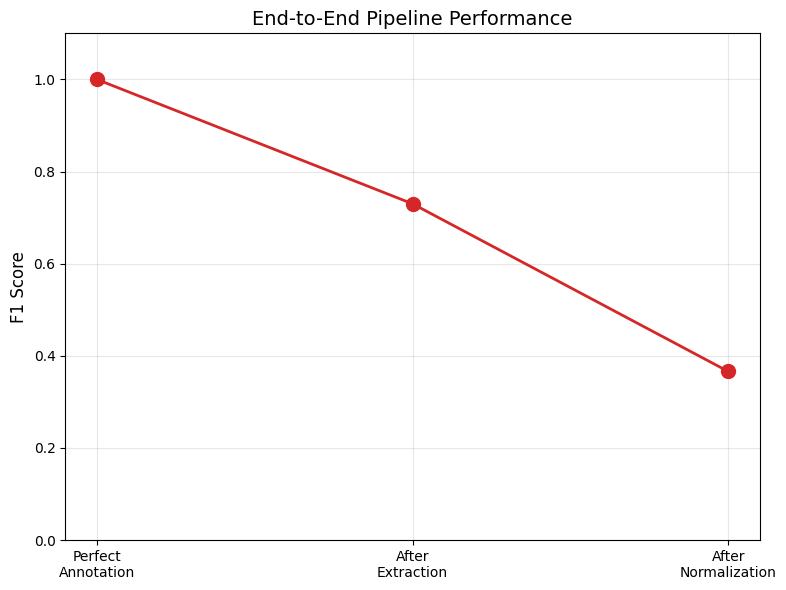

✓ Saved: plot_e2e_waterfall.png


In [ ]:
# Plot 1: Performance Waterfall
fig, ax = plt.subplots(figsize=(8, 6))

stages = ['Perfect\nAnnotation', 'After\nExtraction', 'After\nNormalization']
f1_scores = [1.0, 0.73, strict_results['f1']]  # Replace 0.73 with your actual extraction F1

ax.plot(stages, f1_scores, marker='o', linewidth=2, markersize=10, color='#d62728')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('End-to-End Pipeline Performance', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / "plot_e2e_waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: plot_e2e_waterfall.png")

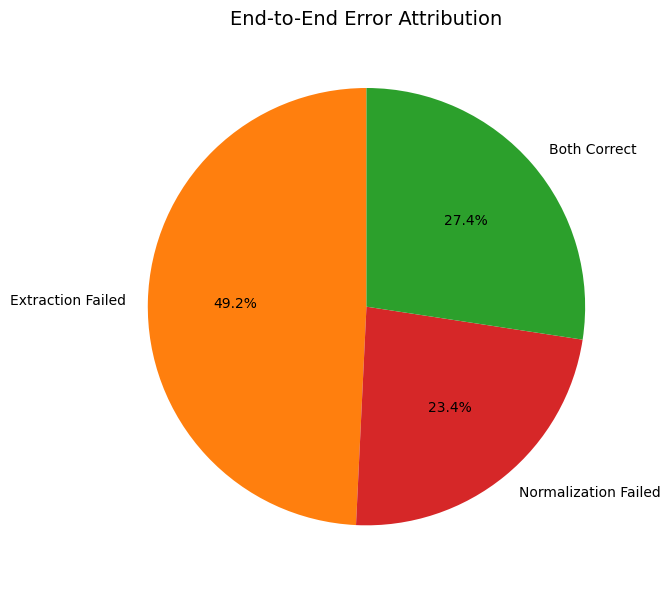

✓ Saved: plot_e2e_errors.png


In [ ]:
# Plot 2: Error Attribution
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate error sources
total_errors = strict_results['fp'] + strict_results['fn']
extraction_errors = strict_results['span_wrong']
normalization_errors = strict_results['span_correct_esco_wrong']

error_sources = {
    'Extraction Failed': extraction_errors,
    'Normalization Failed': normalization_errors,
    'Both Correct': strict_results['tp']
}

colors = ['#ff7f0e', '#d62728', '#2ca02c']
ax.pie(error_sources.values(), labels=error_sources.keys(), autopct='%1.1f%%',
       startangle=90, colors=colors)
ax.set_title('End-to-End Error Attribution', fontsize=14)
plt.tight_layout()
plt.savefig(BASE / "plot_e2e_errors.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: plot_e2e_errors.png")

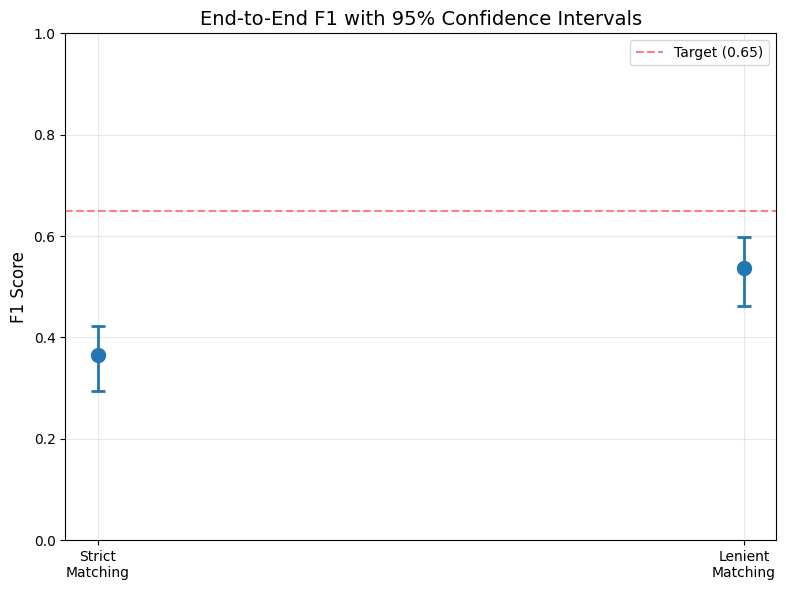

✓ Saved: plot_e2e_confidence.png


In [ ]:
# Plot 3: Confidence Intervals
fig, ax = plt.subplots(figsize=(8, 6))

metrics = ['Strict\nMatching', 'Lenient\nMatching']
means = [strict_mean, lenient_mean]
cis_low = [strict_low, lenient_low]
cis_high = [strict_high, lenient_high]

yerr_low = [m - l for m, l in zip(means, cis_low)]
yerr_high = [h - m for m, h in zip(means, cis_high)]

ax.errorbar(metrics, means, yerr=[yerr_low, yerr_high],
            fmt='o', capsize=5, capthick=2, markersize=10, linewidth=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('End-to-End F1 with 95% Confidence Intervals', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.65, color='r', linestyle='--', alpha=0.5, label='Target (0.65)')
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "plot_e2e_confidence.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: plot_e2e_confidence.png")

## Summary

In [ ]:
print("="*70)
print("END-TO-END EVALUATION COMPLETE")
print("="*70)
print(f"\n RESULTS:")
print(f"\nStrict Matching:")
print(f"  F1: {strict_results['f1']:.3f} [95% CI: {strict_low:.3f}, {strict_high:.3f}]")
print(f"  Precision: {strict_results['precision']:.3f}")
print(f"  Recall: {strict_results['recall']:.3f}")
print(f"\nLenient Matching:")
print(f"  F1: {lenient_results['f1']:.3f} [95% CI: {lenient_low:.3f}, {lenient_high:.3f}]")
print(f"  Precision: {lenient_results['precision']:.3f}")
print(f"  Recall: {lenient_results['recall']:.3f}")
print(f"\n Target from proposal: F1 ≥ 0.65")
if strict_results['f1'] >= 0.65:
    print("✓ TARGET MET!")
else:
    print(f" Fell short by {0.65 - strict_results['f1']:.3f}")
print(f"\n Files saved:")
print(f"  - end_to_end_results.csv")
print(f"  - plot_e2e_waterfall.png")
print(f"  - plot_e2e_errors.png")
print(f"  - plot_e2e_confidence.png")

END-TO-END EVALUATION COMPLETE

 RESULTS:

Strict Matching:
  F1: 0.366 [95% CI: 0.295, 0.422]
  Precision: 0.358
  Recall: 0.375

Lenient Matching:
  F1: 0.540 [95% CI: 0.462, 0.599]
  Precision: 0.525
  Recall: 0.557

 Target from proposal: F1 ≥ 0.65
 Fell short by 0.284

 Files saved:
  - end_to_end_results.csv
  - plot_e2e_waterfall.png
  - plot_e2e_errors.png
  - plot_e2e_confidence.png
